In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imshow,imread,imsave


#Task

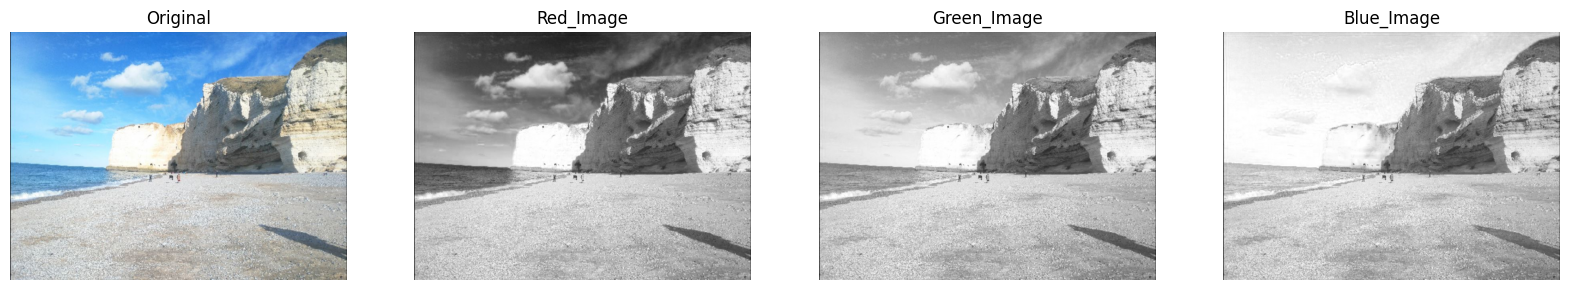

In [20]:
img = imread('sea.jpg')

plt.figure(figsize=(20,8))
plt.subplot(141),plt.imshow(img),plt.title('Original'),plt.axis('off')
plt.subplot(142),plt.imshow(img[:,:,0],cmap='gray'),plt.title('Red_Image'),plt.axis('off')
plt.subplot(143),plt.imshow(img[:,:,1],cmap='gray'),plt.title('Green_Image'),plt.axis('off')
plt.subplot(144),plt.imshow(img[:,:,2],cmap='gray'),plt.title('Blue_Image'),plt.axis('off')
plt.show()

# Resize

1- using slicing

2- using pooling

what is the difference between scaling and resizeing??

Resizing the image changes the dimensions of the image without applying a transformation to the existing contents. Scaling the image will stretch the existing contents to the new dimensions.

C:\Users\Gsamuel\AppData\Local\Temp\ipykernel_16564\4047988924.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(im_)


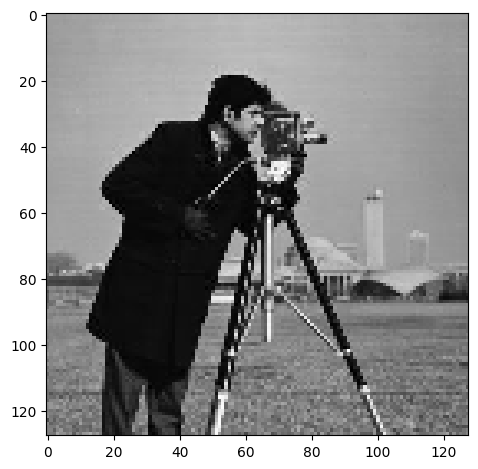

In [21]:
img_camera = imread('camera.jpg')

im_ = img_camera[::2, ::2]
imshow(im_)
plt.show()
#How many pixels of a new image ?? 1/4 from old image

In [22]:
print(f'the size of original image = {img_camera.size}')
print(f'the size of resized image = {im_.size}')

the size of original image = 196608
the size of resized image = 49152


C:\Users\Gsamuel\AppData\Local\Temp\ipykernel_16564\1649827873.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(im_)


the size of image = 196608


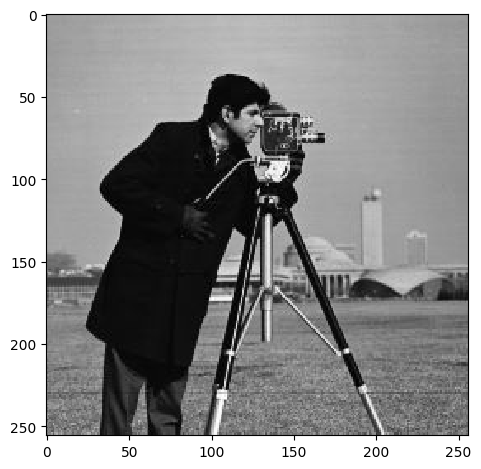

C:\Users\Gsamuel\AppData\Local\Temp\ipykernel_16564\1649827873.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(im_)


the size of image = 49152


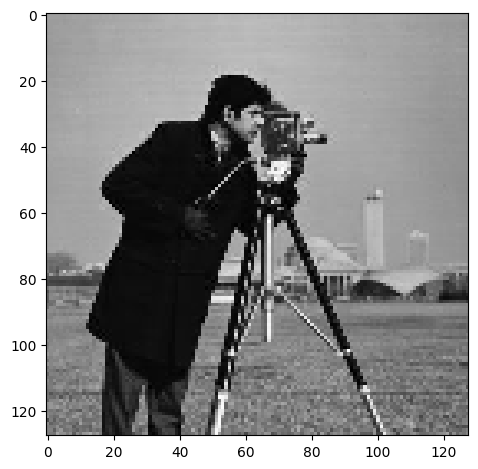

C:\Users\Gsamuel\AppData\Local\Temp\ipykernel_16564\1649827873.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(im_)


the size of image = 22188


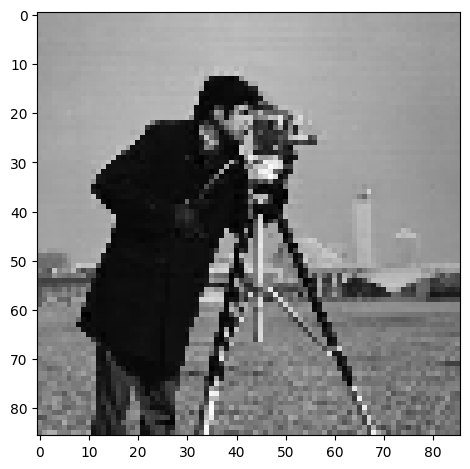

C:\Users\Gsamuel\AppData\Local\Temp\ipykernel_16564\1649827873.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(im_)


the size of image = 12288


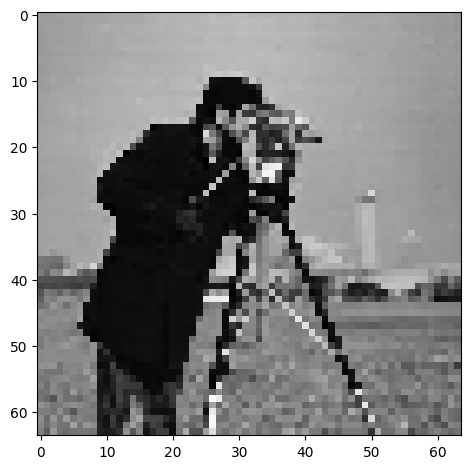

: 

In [ ]:
for s in range(1, 5):
    im_ = img_camera[::s, ::s]
    imshow(im_)
    print(f'the size of image = {im_.size}')
    plt.show()

#Basic of OpenCV

In [9]:
img = cv2.imread('sea.jpg')

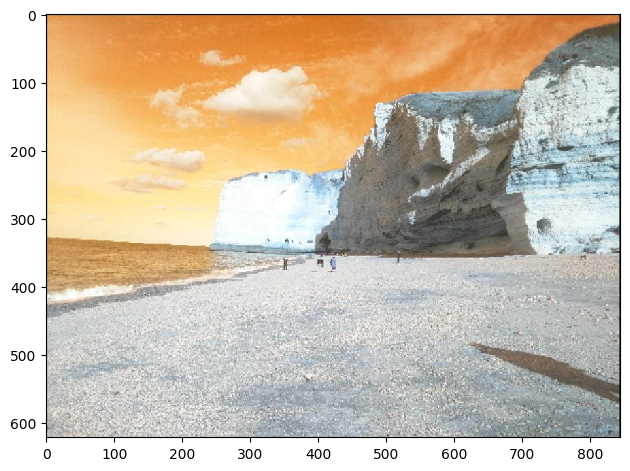

In [11]:
# from google.colab.patches import cv2_imshow
# import cv2
imshow(img)

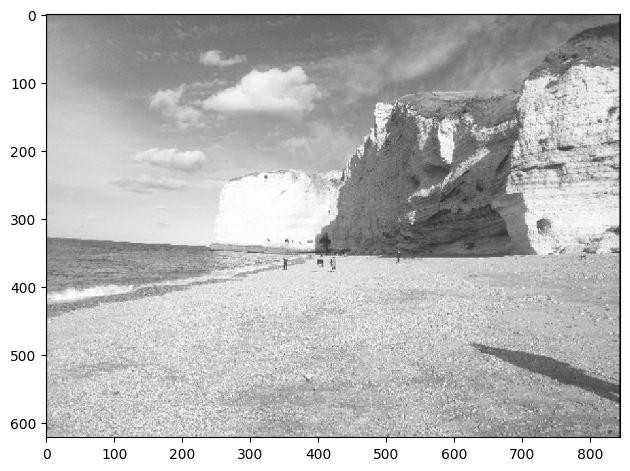

In [12]:
# Convert BGR to grey
img = cv2.imread('sea.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

imshow(img)
imshow(gray)

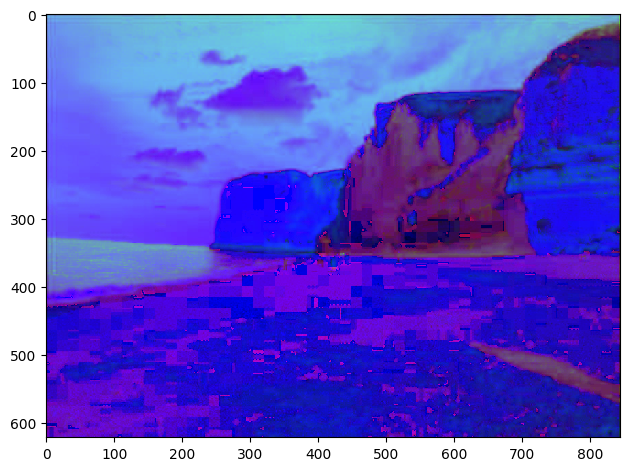

In [13]:
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
imshow(img)
imshow(hsv_img)

Original Dimensions :  (622, 844, 3)
Resized Dimensions :  (311, 422, 3)


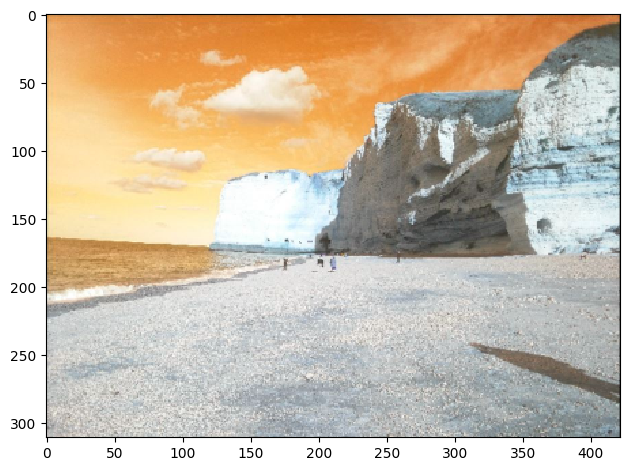

In [14]:
print('Original Dimensions : ',img.shape)

scale_percent = 50 # percent of original size
width = int(img.shape[1] * scale_percent / 100)
height = int(img.shape[0] * scale_percent / 100)
dim = (width, height)

# resize image
resized = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)

print('Resized Dimensions : ',resized.shape)

imshow(resized)

#cv2.INTER_AREA is specifically designed for image shrinking (downsampling). It uses pixel area relation to resample the image.

#Filters

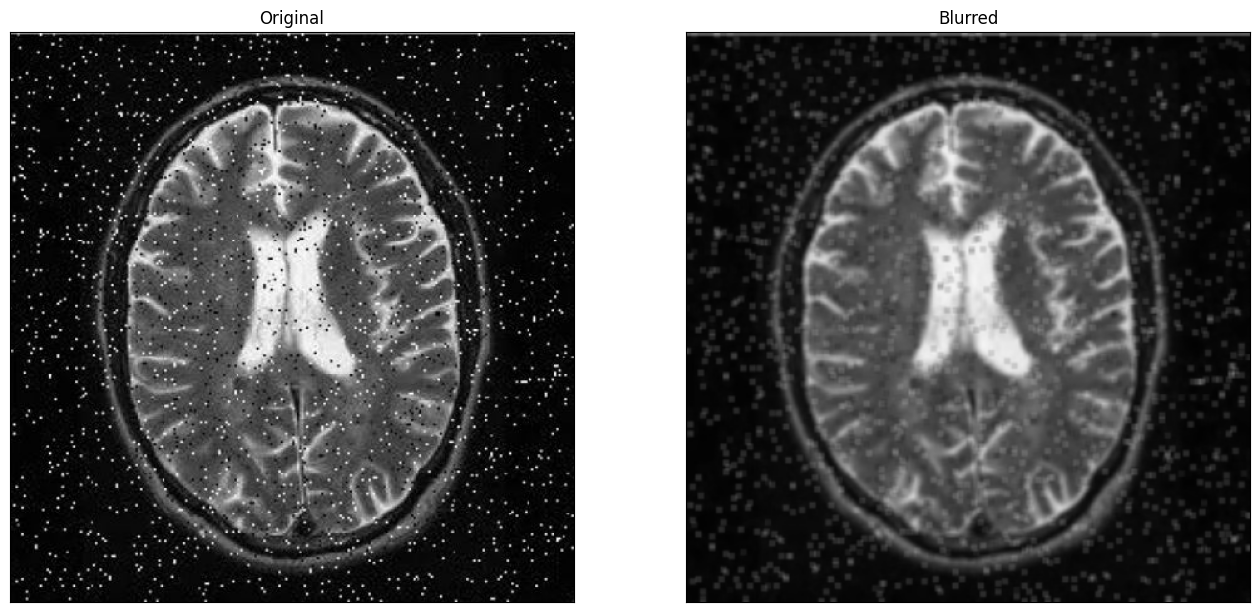

In [16]:
#meanfilter
img = cv2.imread('salt.jpg')

blur = cv2.blur(img,(5,5))

plt.figure(figsize=(16,8))
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.show()

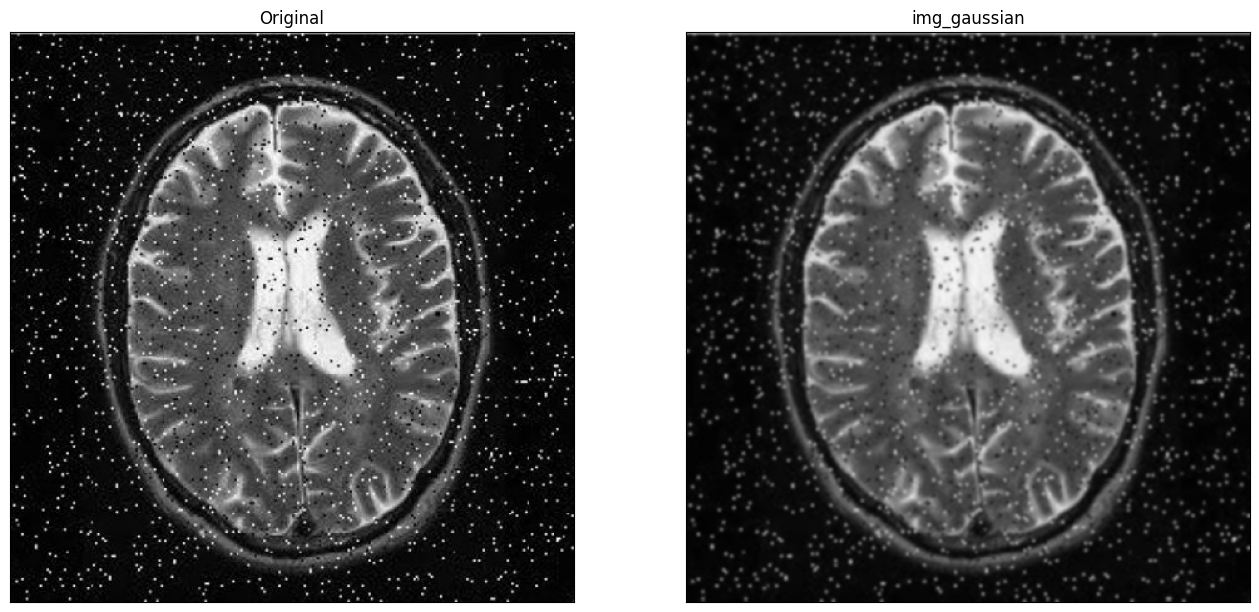

In [17]:
#Gaussian
img = cv2.imread('salt.jpg')
img_gaussian = cv2.GaussianBlur(img,(5,5),0)#0 >> for greyscale image,1 for color image

plt.figure(figsize=(16,8))
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_gaussian),plt.title('img_gaussian')
plt.xticks([]), plt.yticks([])
plt.show()


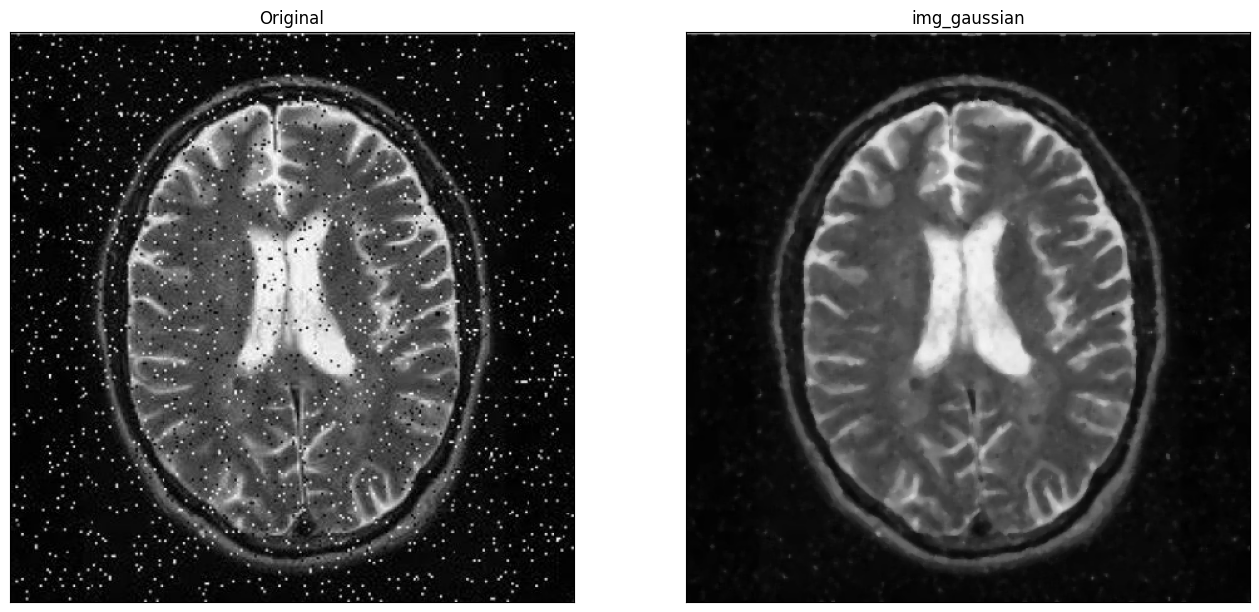

In [18]:
#medain filter
img = cv2.imread('salt.jpg')
median_filter = cv2.medianBlur(img, 5)


plt.figure(figsize=(16,8))
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(median_filter),plt.title('img_gaussian')
plt.xticks([]), plt.yticks([])
plt.show()


The numpy.ravel() functions returns contiguous flattened array(1D array with all the input-array elements and with the same type as it). A copy is made only if needed.

#Histogram

<BarContainer object of 256 artists>

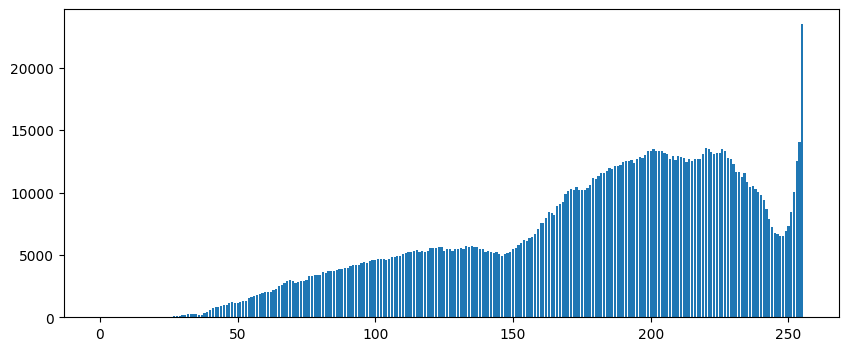

In [19]:
img = cv2.imread('sea.jpg')
hist,bins = np.histogram(img.ravel(), bins=256, range=[0, 256])
# hist,bins = np.histogram(img.flatten(), bins=256, range=[0, 256])

plt.figure(figsize = (10, 4))
plt.bar(x = range(256), height = hist)

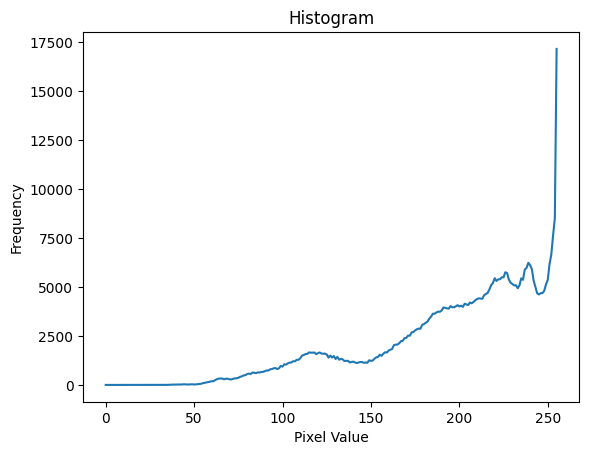

In [20]:
# Calculate the histogram using OpenCV
img = cv2.imread('sea.jpg')
histogram = cv2.calcHist([img], [0], None, [256], [0, 256])

# Plot the histogram using matplotlib
plt.plot(histogram)
plt.title('Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

#[0]: This parameter specifies which channel's histogram you want to compute. For grayscale images,
# None: This parameter represents the mask. You can use a mask to calculate the histogram only for specific
# regions of the image. If you pass None, the histogram will be computed for the entire image.

#Equalization Histogram

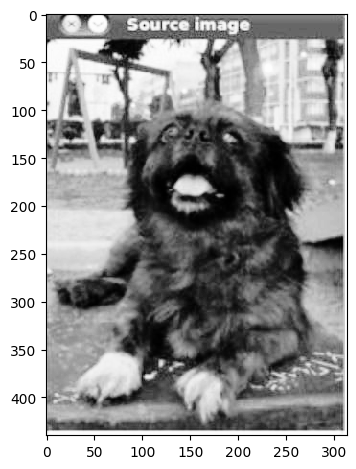

In [23]:
# read a image using imread
img = cv2.imread('dog.jpg')

# # creating a Histograms Equalization
# # of a image using cv2.equalizeHist()
# equ = cv2.equalizeHist(img)

# # stacking images side-by-side
# res = np.hstack((img, equ))

# # show image input vs output
# cv2.imshow(\'image\', res)

src = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
dst = cv2.equalizeHist(src)
imshow(src)
imshow(dst)

#Operations

##Sobel

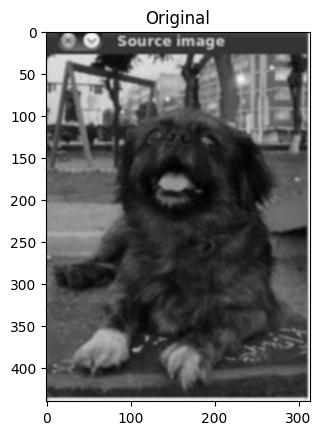

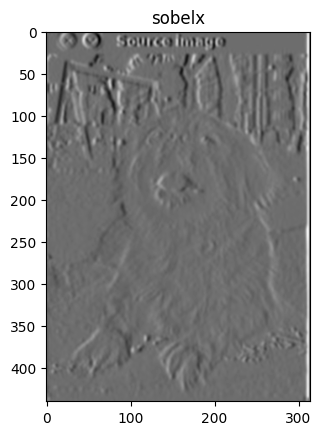

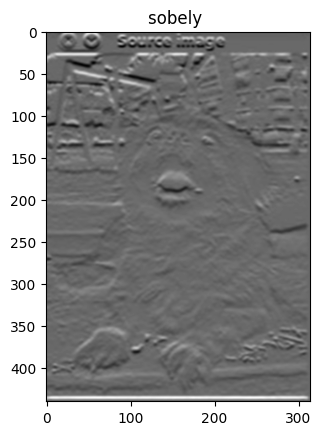

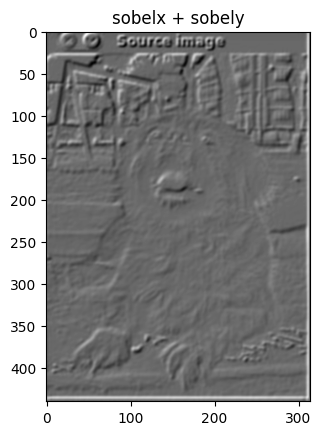

In [24]:
img=cv2.imread('dog.jpg')
# converting to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# remove noise
img = cv2.GaussianBlur(gray,(3,3),0)

# convolute with proper kernels
sobelx = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=5)  # x
sobely = cv2.Sobel(img,cv2.CV_64F,0,1,ksize=5)  # y

plt.imshow(img,cmap = 'gray')
plt.title('Original'),
plt.show()

plt.imshow(sobelx,cmap = 'gray')
plt.title('sobelx'),
plt.show()

plt.imshow(sobely,cmap = 'gray')
plt.title('sobely '),
plt.show()

plt.imshow(sobelx + sobely,cmap = 'gray')
plt.title('sobelx + sobely'),

plt.show()

#  cv2.CV_64F: Data type for the output gradient image. cv2.CV_64F corresponds to a 64-bit floating-point data type.
#  1, 0 >>>>> calculates the gradient in the x-direction (horizontal gradient)
#  0, 1 >>>>> calculates the gradient in the y-direction (vertical gradient)

##perwitt operator

The Prewitt operator was developed by Judith M. S. Prewitt. Prewitt operator is used for edge detection in an image. Prewitt operator detects both types of edges, these are:

1- Horizontal edges or along the x-axis.

2- Vertical Edges or along the y-axis.

Steps:

Read the image.

Convert into grayscale if it is colored.

Convert into the double format.

Define the mask or filter.

Detect the edges along X-axis.

Detect the edges along Y-axis.

Combine the edges detected along the X and Y axes.

Display all the images.

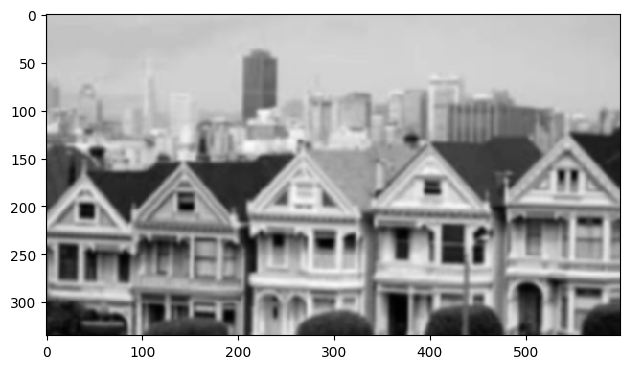

In [25]:
img=cv2.imread('house.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_gaussian = cv2.GaussianBlur(gray,(3,3),0)
imshow(img_gaussian)

In [26]:
kernelx = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
kernely = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
img_prewittx = cv2.filter2D(img_gaussian, -1, kernelx)
img_prewitty = cv2.filter2D(img_gaussian, -1, kernely)

# -1 indicates that the destination image will have the same depth as the input image

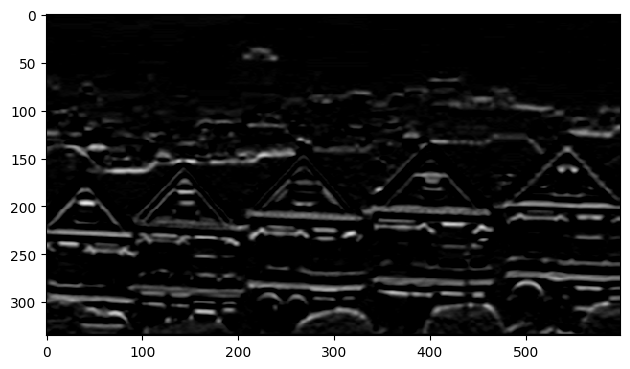

In [27]:
imshow(img_prewittx)

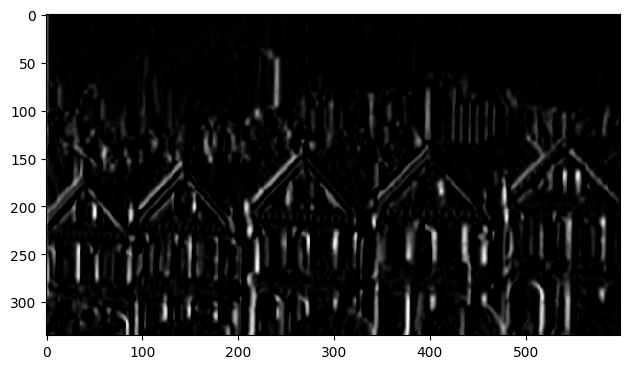

In [28]:
imshow(img_prewitty)

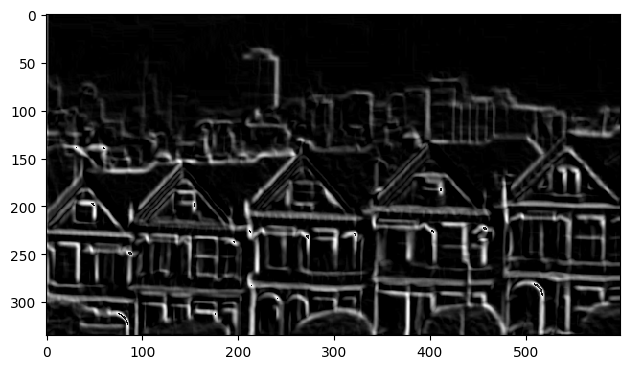

In [29]:
imshow(img_prewittx+ img_prewitty)

##Canny

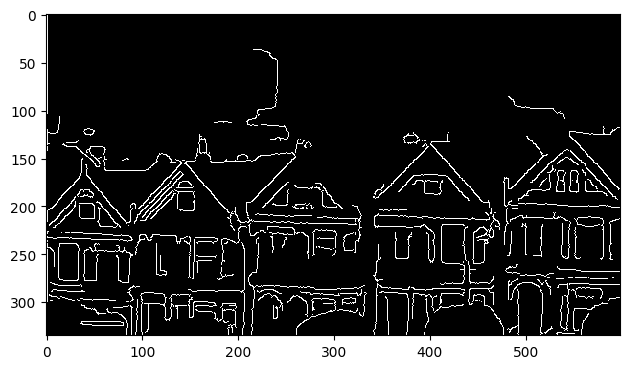

In [31]:
img=cv2.imread('house.jpg')
img_canny = cv2.Canny(img,100,200)
imshow(img_canny)

# 100: This is the lower threshold for edge linking. It's a threshold value used to determine which edges are considered strong and which are considered weak.

# 200: This is the upper threshold for edge linking. It's used to link strong edges together into a continuous line.

##Laplacian_operator

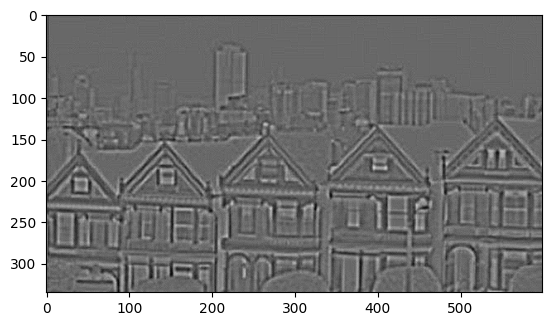

In [32]:
img=cv2.imread('house.jpg')

# converting to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# remove noise
img = cv2.GaussianBlur(gray,(3,3),0)

# convolute with proper kernels
laplacian = cv2.Laplacian(img,cv2.CV_64F)

plt.imshow(laplacian,cmap = 'gray')

##comarison

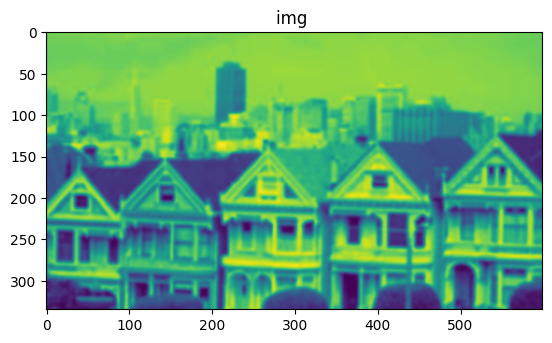

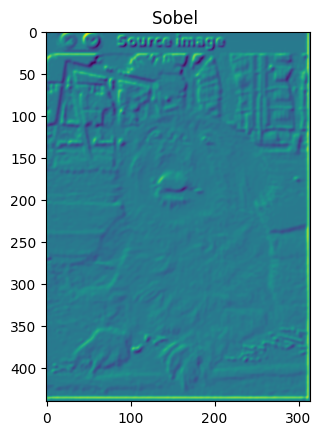

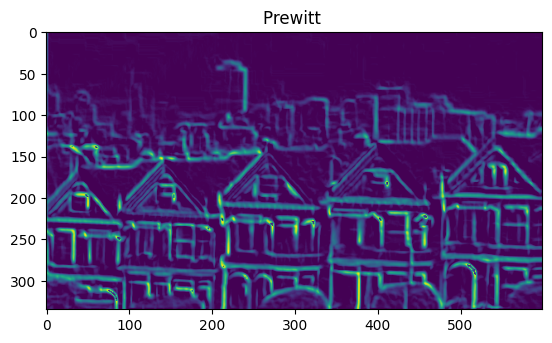

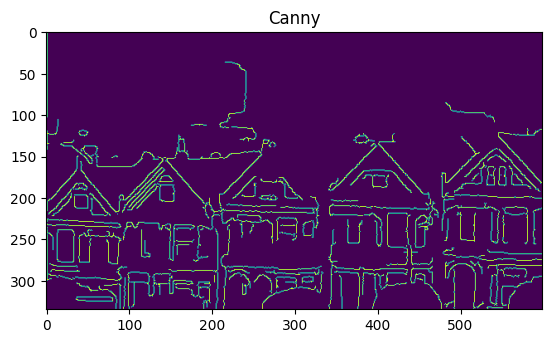

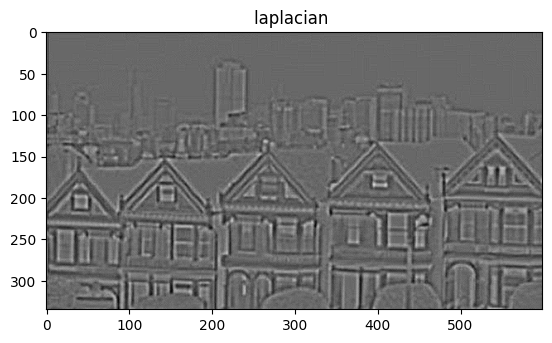

In [33]:
plt.imshow(img)
plt.title('img ')
plt.show()

plt.imshow( sobelx + sobely)
plt.title('Sobel ')
plt.show()

plt.imshow( img_prewittx + img_prewitty)
plt.title('Prewitt ')
plt.show()

plt.imshow( img_canny)
plt.title('Canny')
plt.show()

plt.imshow(laplacian,cmap = 'gray')
plt.title('laplacian ')
plt.show()


#Segmentation

##Manually Histogram

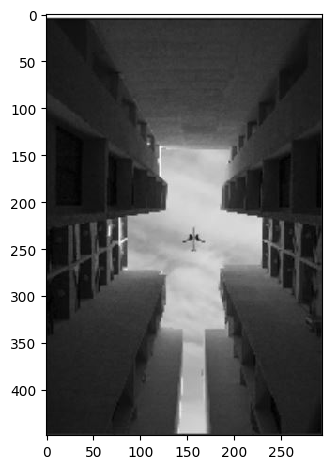

In [35]:
im = imread('airplane.jpg')
imshow(im)
plt.show()

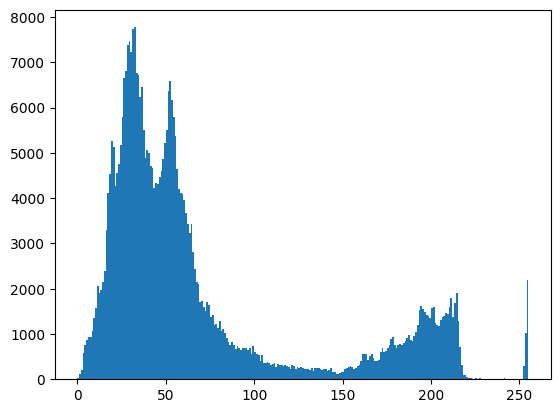

In [36]:
_=plt.hist(im.flatten(), bins = range(256))
plt.show()

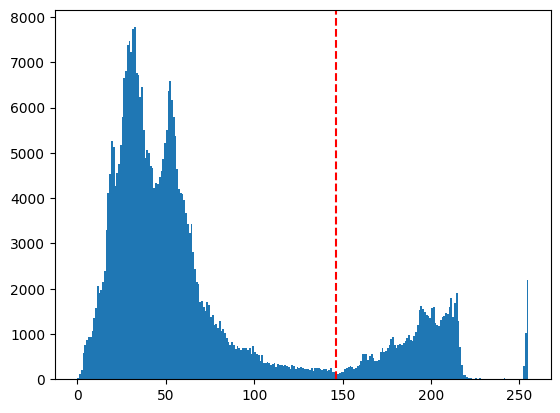

In [37]:
_=plt.hist(im.flatten(), bins = range(256))
plt.axvline(x = 146, linestyle = '--', color = 'red')
plt.show()


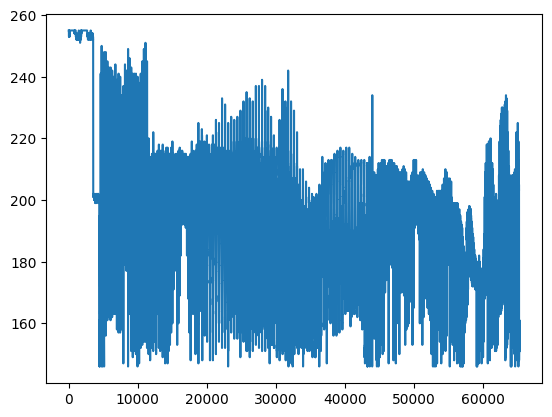

In [38]:
plt.plot(im[im >= 146])
plt.show()

##Histogram-Centroid

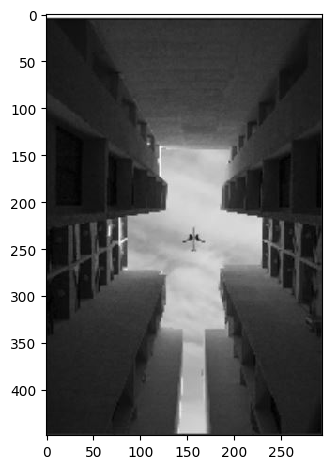

In [39]:
im = imread('airplane.jpg')
imshow(im)
plt.show()

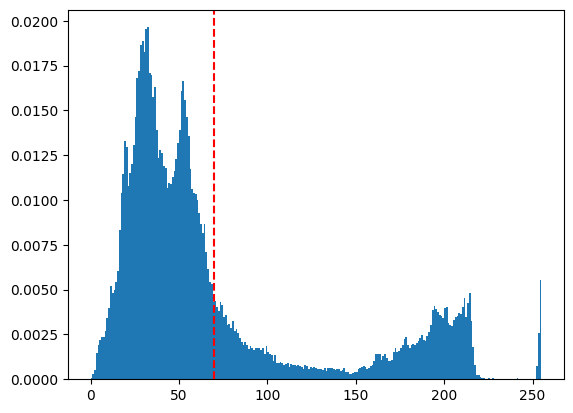

In [40]:
norm_hist,bins,_=plt.hist(im.flatten(), bins = range(256),density=True)
bins=bins[:-1]
hist_centroid=round((norm_hist*bins).sum())
plt.axvline(x = hist_centroid, linestyle = '--', color = 'red')
plt.show()

#OTSU_Thre_sholding

In [41]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

In [43]:
img = cv.imread('noise.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

In [44]:
# global thresholding, by default it will be in the middle between 0 and 256, so make it =127
ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
#cv.THRESH_BINARY >>> that will divide image to white for forground(object) and black for background
#ret1 >>> true if image can be applied a threshold in it and false otherwise

In [45]:
# Otsu's thresholding, change from 127 to 0, it will be understanded: i need an otsu thresholding
ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

In [46]:
# Otsu's thresholding after Gaussian filtering
blur = cv.GaussianBlur(img,(5,5),0) # zero here mean greyscale image and 1 for color image and -1 for other
ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

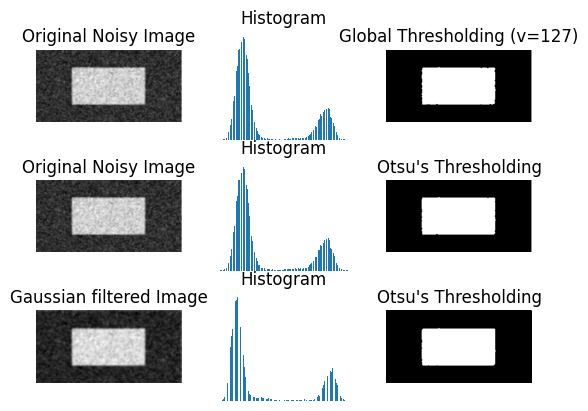

In [47]:
# plot all the images and their histograms
images = [img, 0, th1,
          img, 0, th2,
          blur, 0, th3]

titles = ['Original Noisy Image','Histogram','Global Thresholding (v=127)',
          'Original Noisy Image','Histogram',"Otsu's Thresholding",
          'Gaussian filtered Image','Histogram',"Otsu's Thresholding"]
for i in range(3):
 plt.subplot(3,3,i*3+1),
 plt.imshow(images[i*3],'gray')
 plt.title(titles[i*3])
 plt.axis('off')

 plt.subplot(3,3,i*3+2),
 plt.hist(images[i*3].ravel(),256)
 plt.title(titles[i*3+1])
 plt.axis('off')

 plt.subplot(3,3,i*3+3),
 plt.imshow(images[i*3+2],'gray')
 plt.title(titles[i*3+2])
 plt.axis('off')
plt.show()

#.ravel(): This function flattens the image array into a 1D array.
# In the context of image processing, this is often used to convert a 2D image into a 1D array of pixel values.